# Fig S15 -- observed vs CIPHER-predicted effective number of responding genes

Reproduces Fig S15: for every perturbation across the raw-dataset panel, compares the **observed** effective number of responding genes (Shannon N_eff, excluding the target) against the **CIPHER-predicted** N_eff, filtered by forward-prediction R^2.

Three analysis blocks:
1. **Observed vs predicted N_eff** at a single R^2>=0.5 filter (scatter, log-log, within-dataset rank scatter, per-dataset Spearman forest, dataset medians, ratio histogram) plus a shared within-dataset **permutation null** written to `.npz`.
2. **Full R^2-cutoff sweep** (0.00->0.90) with a four-panel composite.
3. **R^2 sweep 0.30->0.90** (the published composite, Panel A y-axis fixed 0-1) plus a dataset-median plot at R^2>=0.50.

Helper engine: `notebooks/src/suppl_effn.py` (not part of the cipher package). A few cell-specific helper variants are redefined inline for a faithful 1:1 reproduction.

**Input:** `response_breadth_per_perturbation.tsv` (per-perturbation observed/predicted N_eff + forward R^2 for the 27-dataset panel), expected under `$CIPHER_DATA_DIR/suppl/figS15/`. *Verification pending this table.*

In [1]:
import os, sys
# route tqdm progress bars to text (stderr -> log) instead of un-renderable ipywidgets
import importlib as _il
try:
    _std_tqdm = _il.import_module('tqdm.std').tqdm
    for _m in ('tqdm', 'tqdm.auto', 'tqdm.notebook', 'tqdm.autonotebook'):
        try: _il.import_module(_m).tqdm = _std_tqdm
        except Exception: pass
except Exception:
    pass
from pathlib import Path

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'suppl' else os.path.join(os.getcwd(), 'notebooks'))
from src.suppl_effn import *
DATA_DIR = os.environ["CIPHER_DATA_DIR"]
SUPPL = os.path.join(DATA_DIR, "suppl")
OUTDIR = os.environ.get("SUPPL_OUT", "resources/repro/figS15")
os.makedirs(OUTDIR, exist_ok=True)
from src.logutil import route_logs  # verbose logs -> .log, plots stay in-cell
route_logs("figS15_effective_N")
# input table (per-perturbation observed/predicted N_eff + forward R2 for the 27-dataset panel)
BREADTH_PATH = Path(os.path.join(SUPPL, "figS15", "response_breadth_per_perturbation.tsv"))
print("data dir:", DATA_DIR)
print("breadth table:", BREADTH_PATH)

[logs] verbose output -> ../../resources/repro/figS15/logs/figS15_effective_N.log
data dir: $CIPHER_DATA_DIR
breadth table: $SUPPL/figS15/response_breadth_per_perturbation.tsv


In [2]:
# inject notebook config into the run + cluster modules so their functions resolve it
import src.run_figS15 as R
import src.suppl_effn as C
_cfg = {k: v for k, v in globals().items() if k.isupper() or k in ("DATA_DIR", "SUPPL", "OUTDIR")}
R.__dict__.update(_cfg)
C.__dict__.update(_cfg)

## Block 1 -- observed vs CIPHER-predicted N_eff (R2>=0.5) + permutation null (.npz)

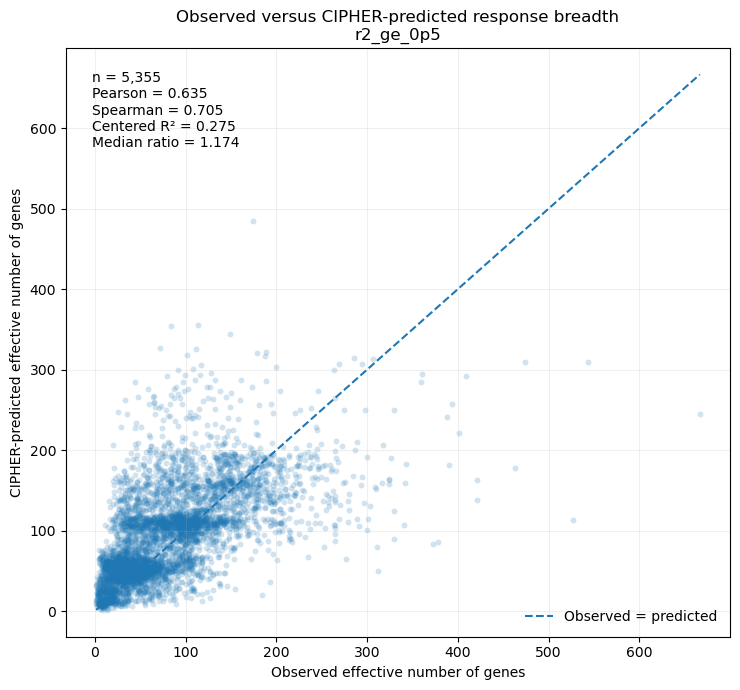

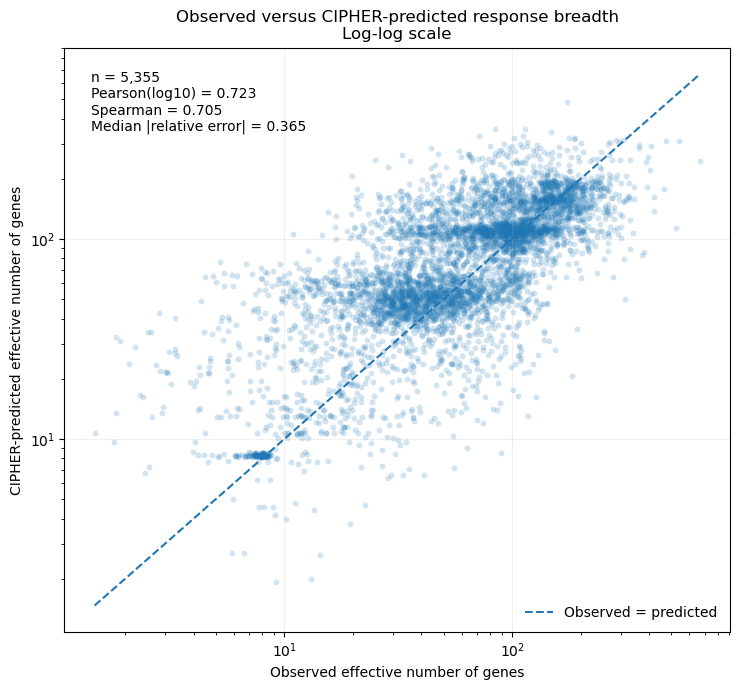

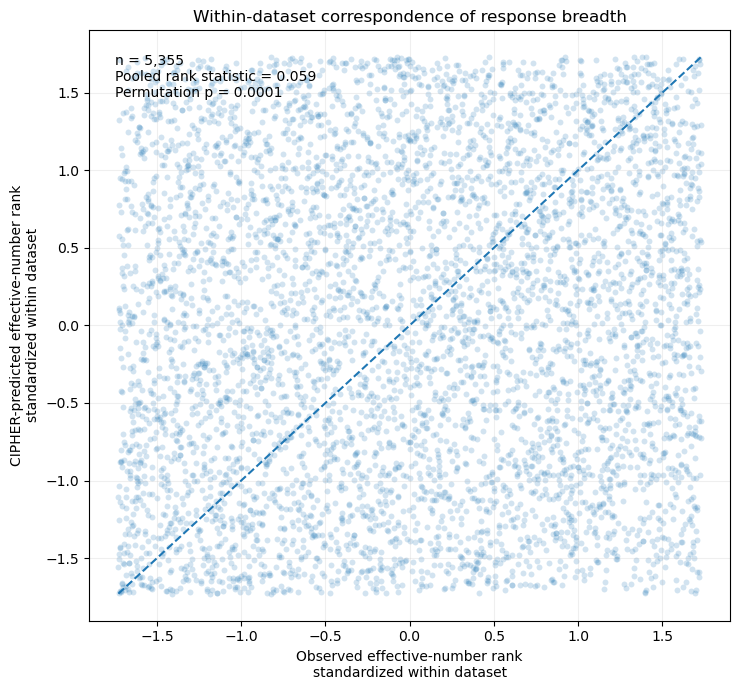

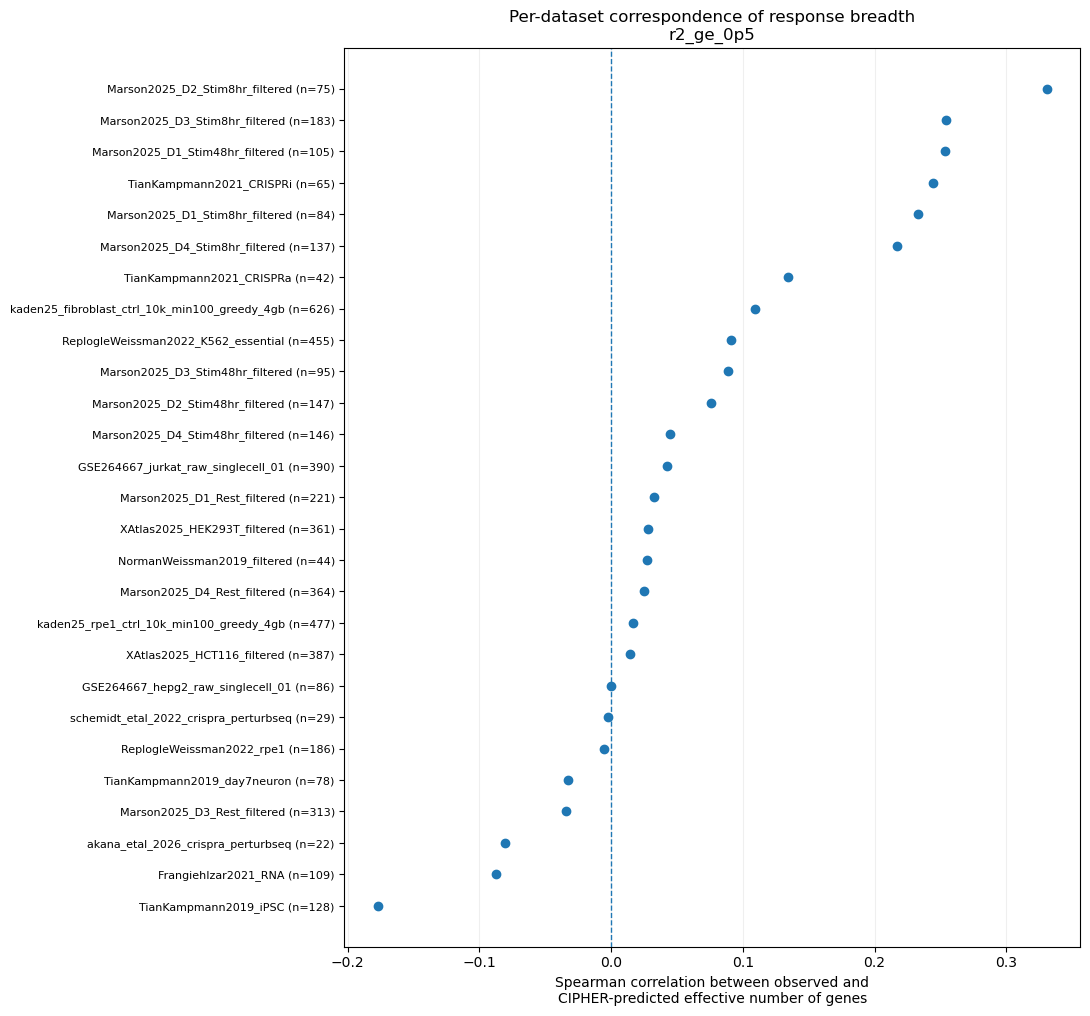

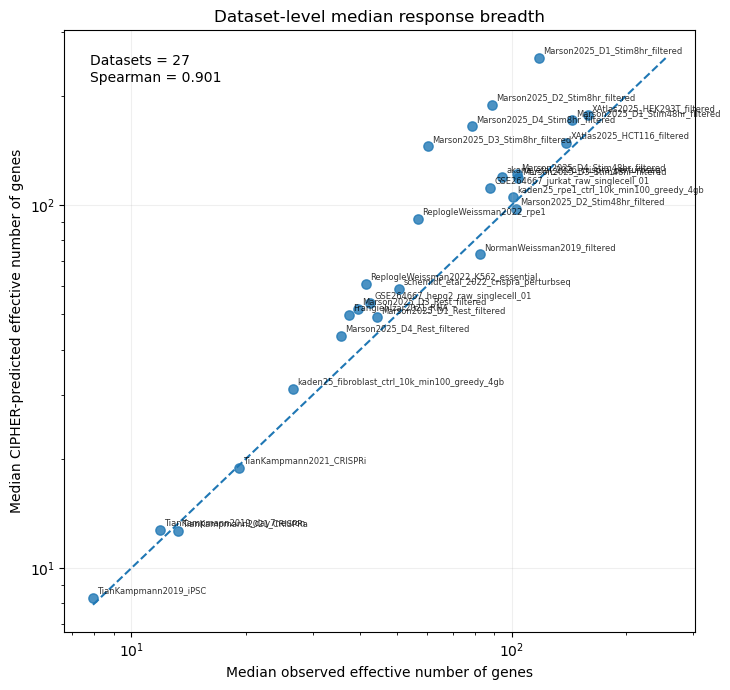

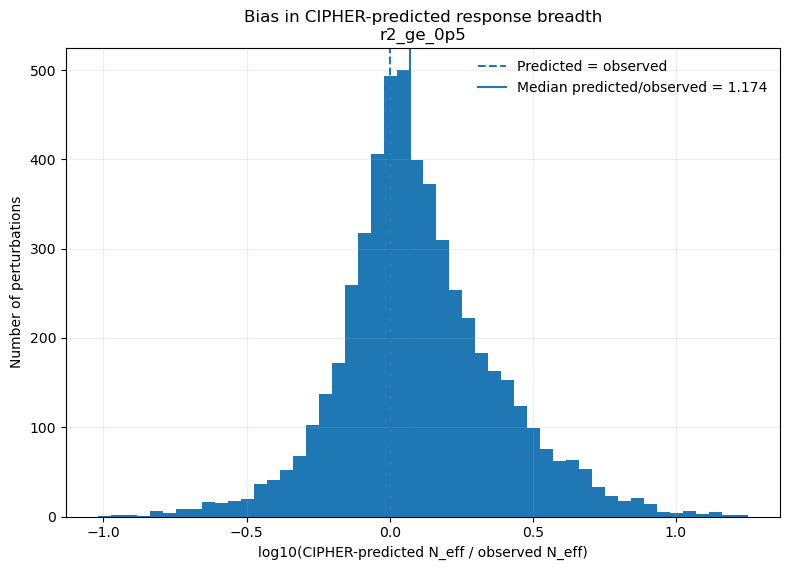

In [3]:
R.block1_observed_vs_predicted_neff()

## Block 2 -- full R2-cutoff sweep (0.00 to 0.90)

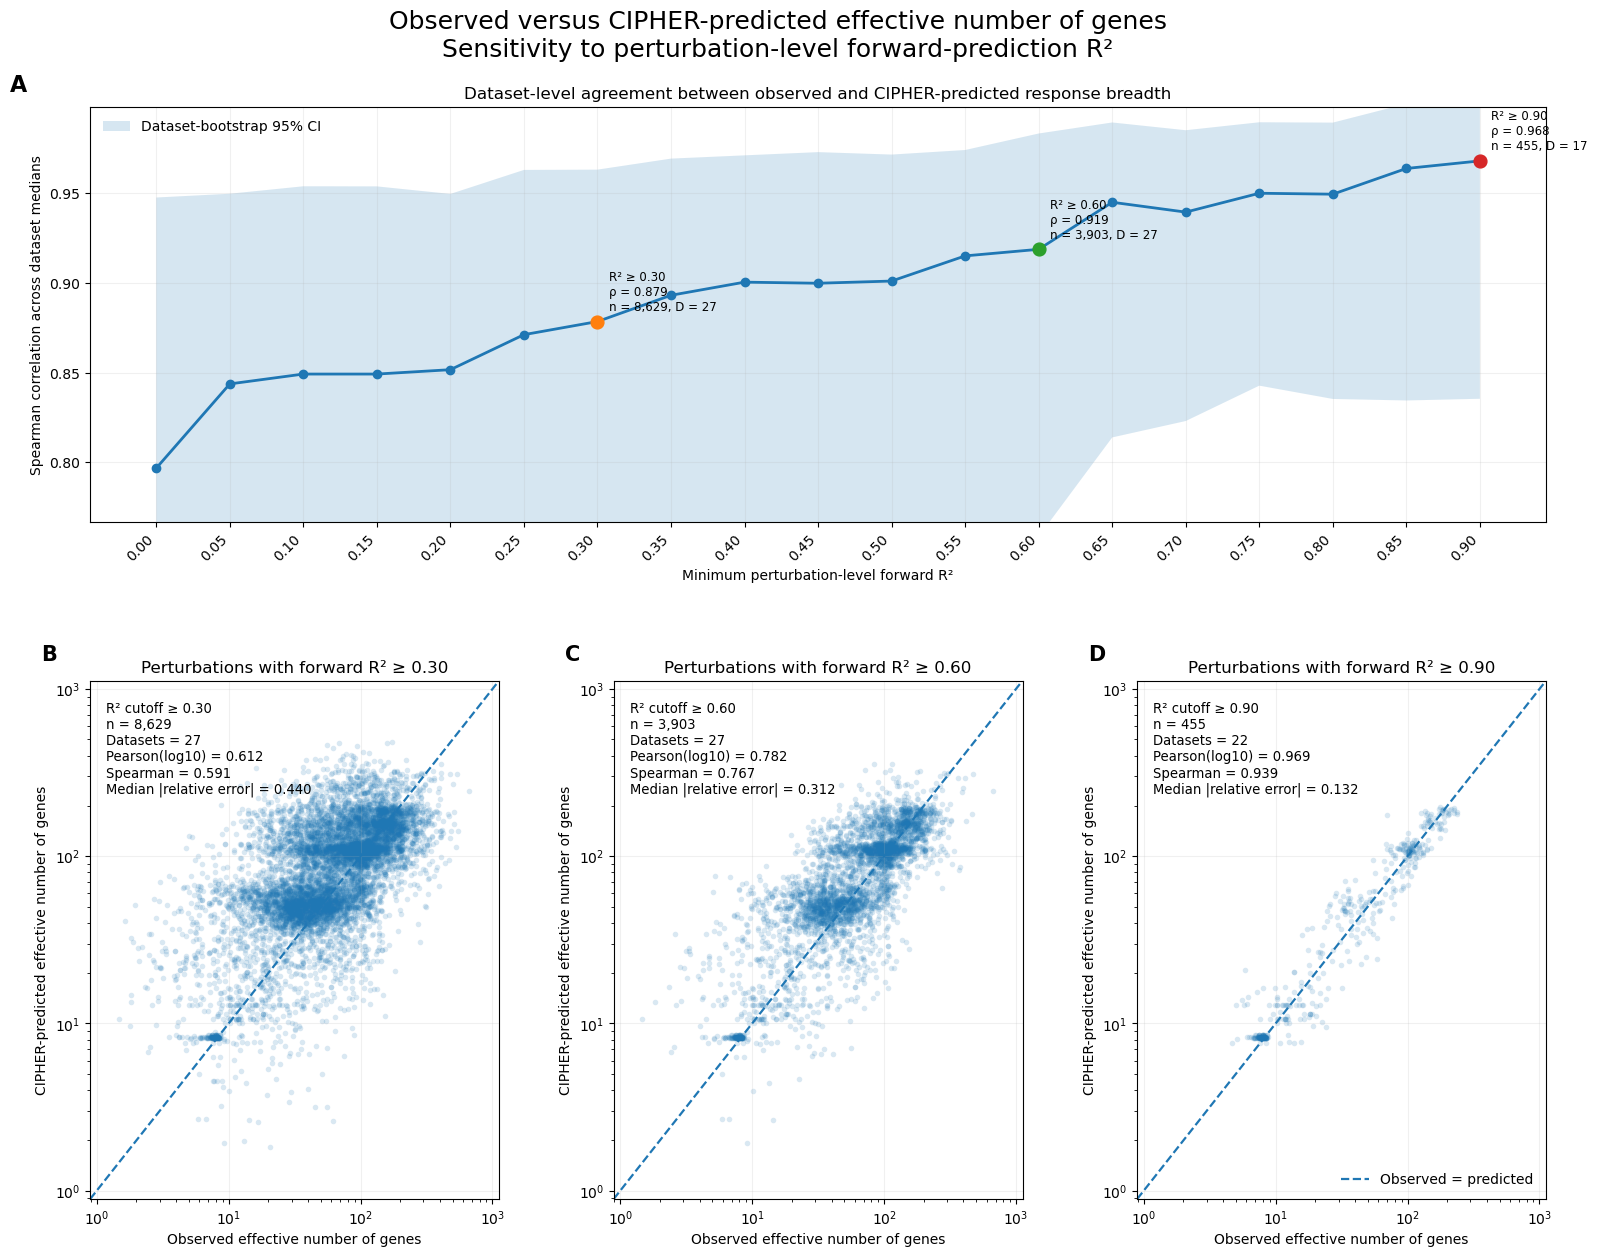

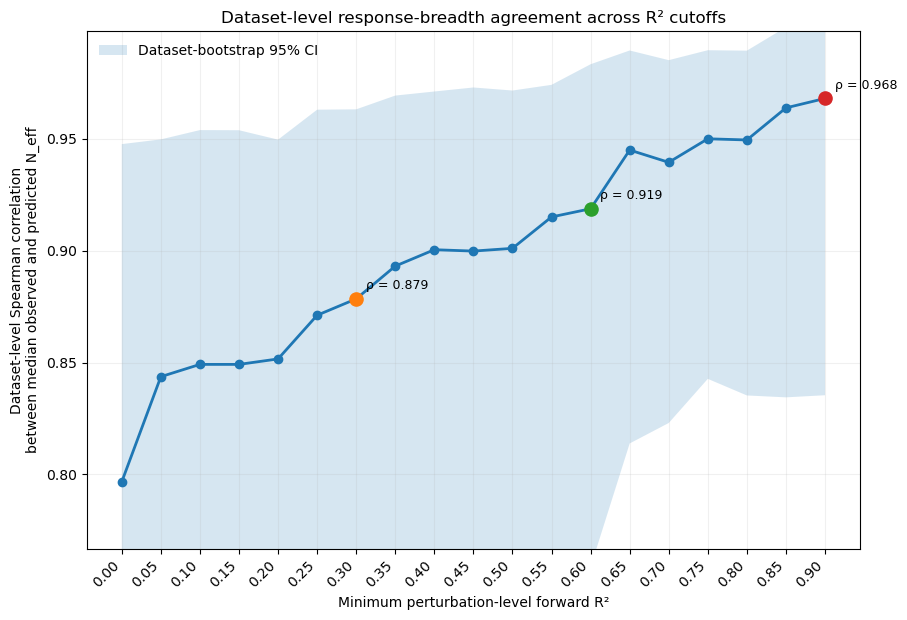

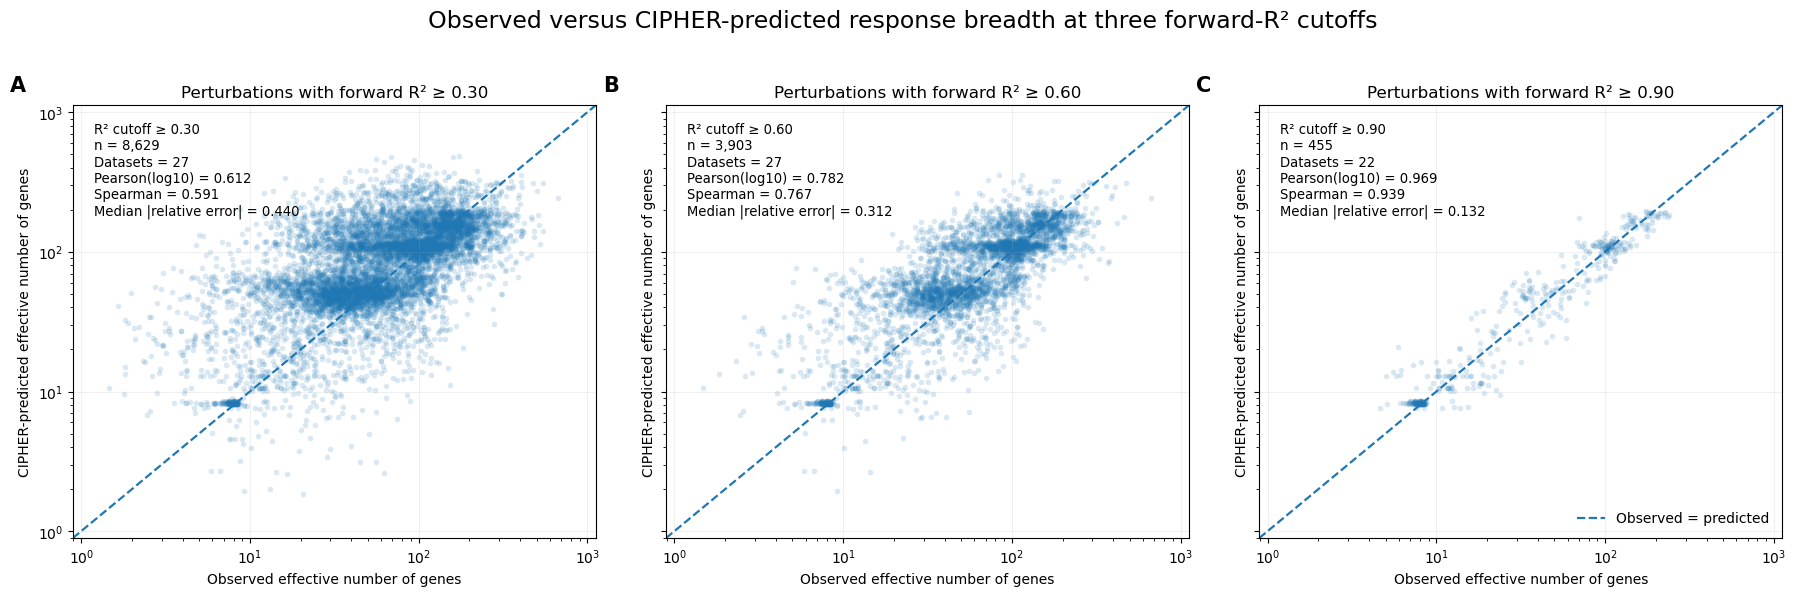

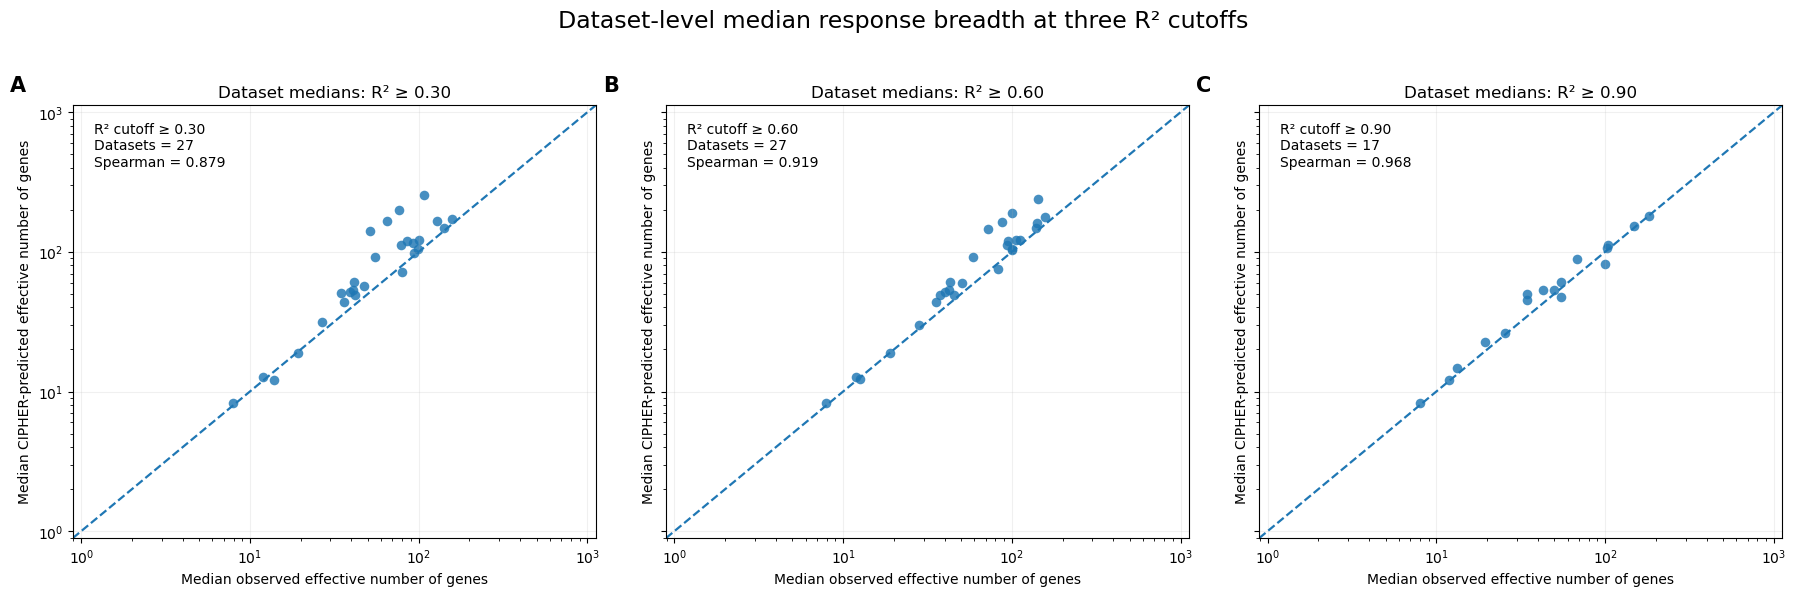

In [4]:
R.block2_full_r2_cutoff_sweep()

## Block 3 -- R2 sweep 0.30 to 0.90 (published composite) + dataset-median plot

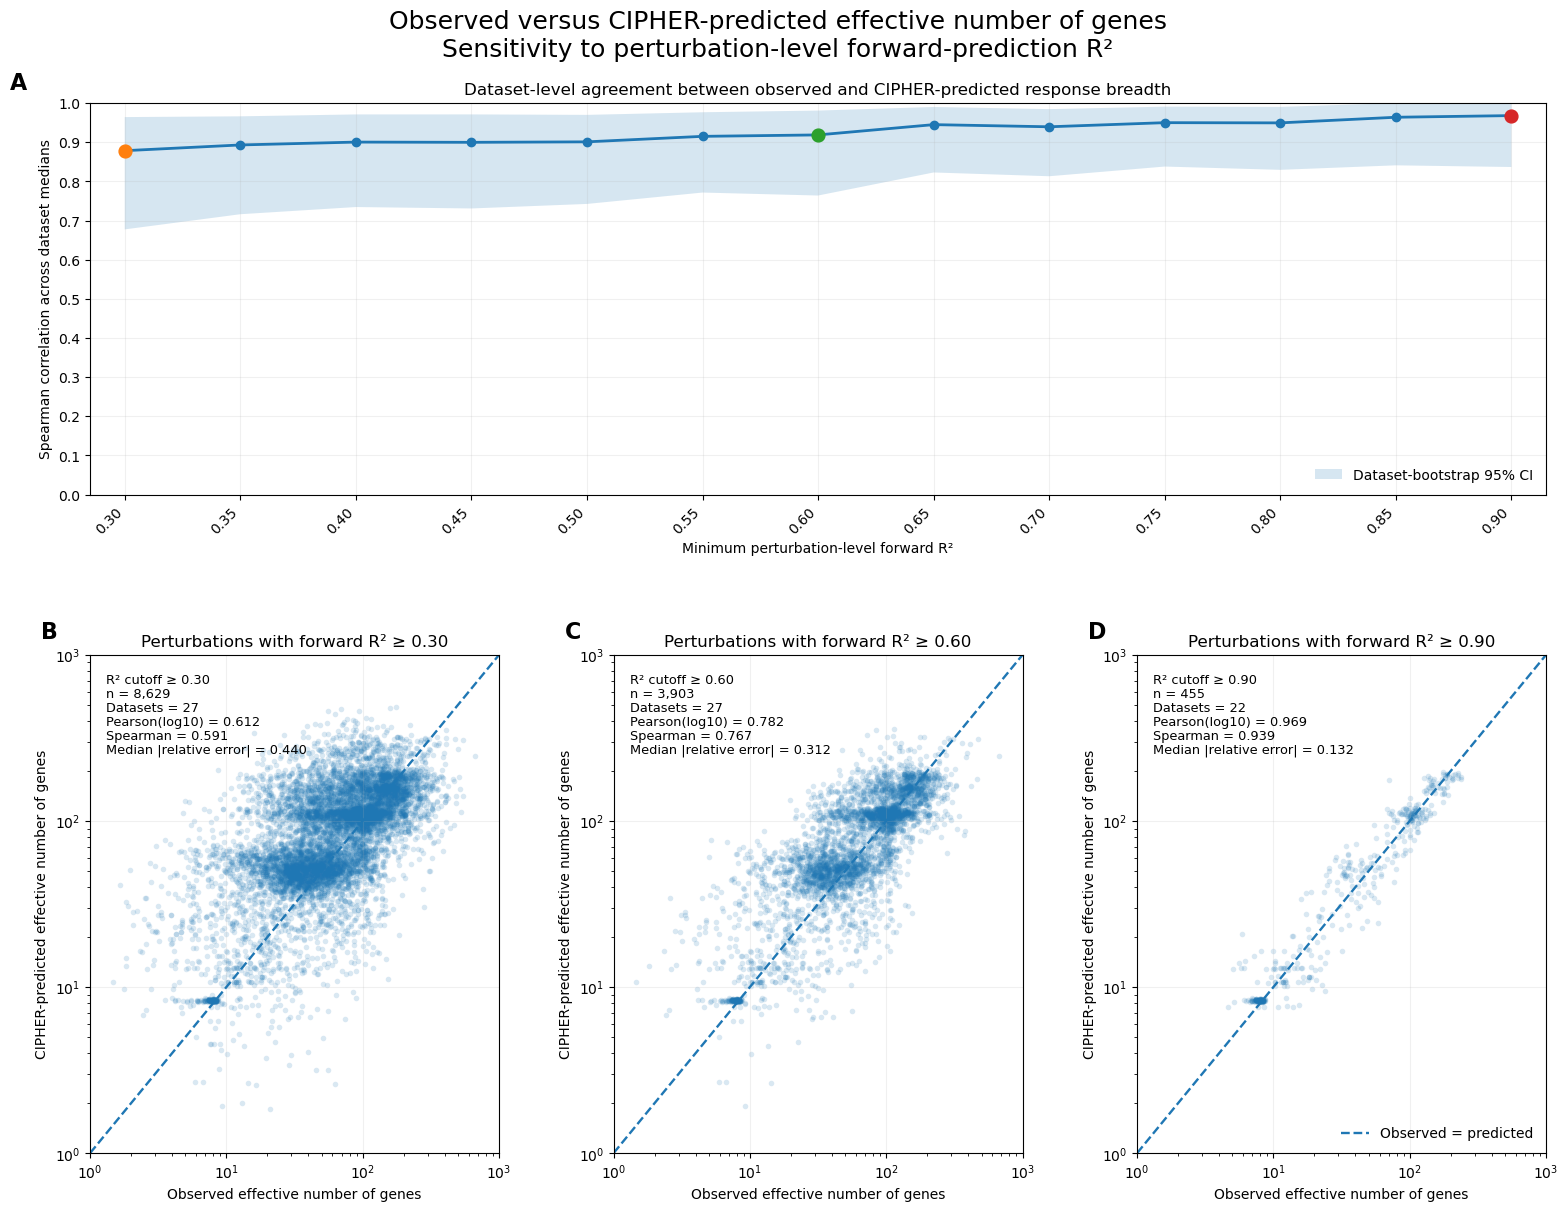

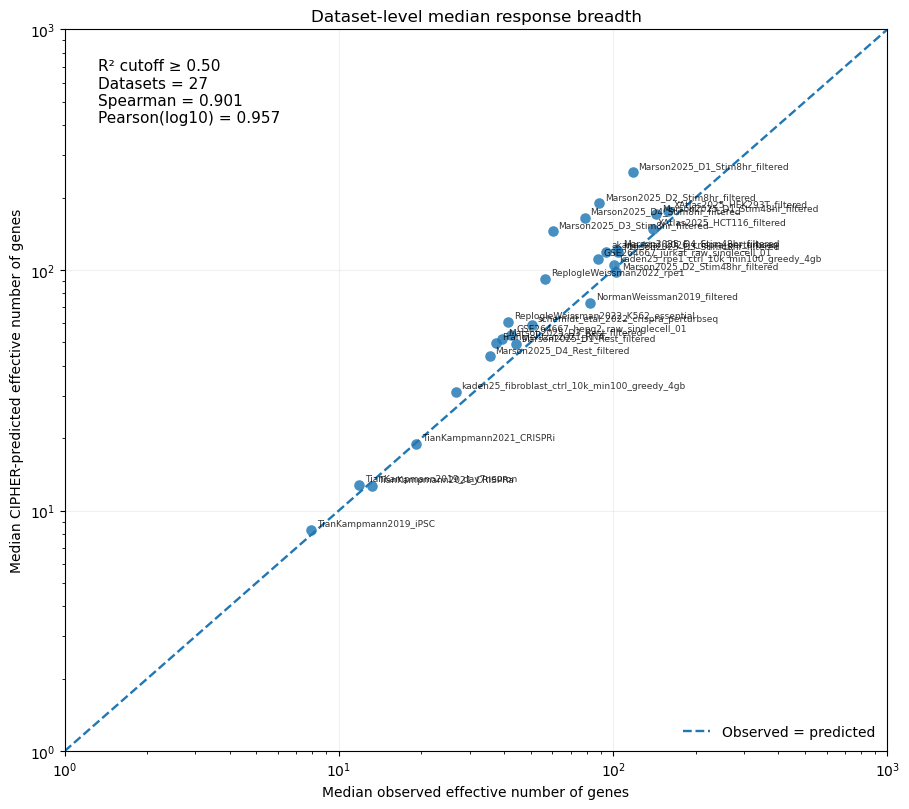

In [5]:
R.block3_r2_sweep_published()